# Engle-Granger ECM: quan hệ dài hạn và ngắn hạn

Notebook này bổ sung đúng phần còn thiếu quan trọng của đề tài: **ước lượng mối quan hệ dài hạn và cơ chế điều chỉnh ngắn hạn** giữa GDP và các biến vĩ mô.

Điểm mạnh của notebook:
- Dùng **real GDP level** thay vì dựa hoàn toàn vào GDP danh nghĩa nội suy.
- Tách rõ:
  - **long-run equation**
  - **error-correction term**
  - **short-run dynamics**
- Có thêm **robustness theo định nghĩa lãi suất**: real interest rate vs lending rate vs deposit rate.


In [2]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from IPython.display import display, Markdown

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = Path("notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
CACHE_PATH = OUTPUT_DIR / "01_world_bank_ecm_source.csv"
LOCAL_ANNUAL_PATH = Path("secondary_data_annual.csv")

COUNTRY = "VNM"
START_YEAR = 1995
END_YEAR = 2024

INDICATORS = {
    "NY.GDP.MKTP.KD": "Real_GDP",
    "FP.CPI.TOTL.ZG": "Inflation",
    "FR.INR.RINR": "Real_Interest",
    "FR.INR.LEND": "Lending_Rate",
    "FR.INR.DPST": "Deposit_Rate",
    "BX.KLT.DINV.WD.GD.ZS": "FDI_pct_GDP",
    "NE.EXP.GNFS.ZS": "Export_pct_GDP",
}


## 1. Tải dữ liệu World Bank (hoặc dùng cache)


In [3]:

def fetch_world_bank(country: str, indicators: dict, start_year: int, end_year: int) -> pd.DataFrame:
    indicator_string = ";".join(indicators.keys())
    url = (
        f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator_string}"
        f"?source=2&format=json&per_page=20000"
    )
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    payload = response.json()

    if not isinstance(payload, list) or len(payload) < 2:
        raise ValueError("World Bank API trả về dữ liệu không đúng định dạng.")

    rows = []
    for item in payload[1]:
        year = item.get("date")
        indicator = item.get("indicator", {}).get("id")
        value = item.get("value")
        if year is None or indicator is None:
            continue
        try:
            year = int(year)
        except Exception:
            continue
        if start_year <= year <= end_year:
            rows.append({"Year": year, "indicator": indicator, "value": value})

    out = pd.DataFrame(rows)
    out["value"] = pd.to_numeric(out["value"], errors="coerce")
    out = (
        out.pivot_table(index="Year", columns="indicator", values="value", aggfunc="first")
           .reset_index()
           .rename(columns=indicators)
           .sort_values("Year")
           .reset_index(drop=True)
    )
    return out

try:
    df = fetch_world_bank(COUNTRY, INDICATORS, START_YEAR, END_YEAR)
    df.to_csv(CACHE_PATH, index=False)
    source_used = "world_bank_api"
except Exception as exc:
    if CACHE_PATH.exists():
        df = pd.read_csv(CACHE_PATH)
        source_used = f"cache: {CACHE_PATH}"
    else:
        raise RuntimeError(
            "Không thể tải dữ liệu World Bank và cũng không có cache cũ. "
            "Hãy kiểm tra internet rồi chạy lại notebook."
        ) from exc

df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
display(Markdown(f"**Nguồn đang dùng:** `{source_used}`"))
display(df.head())


**Nguồn đang dùng:** `world_bank_api`

indicator,Year,FDI_pct_GDP,Inflation,Deposit_Rate,Lending_Rate,Real_Interest,Export_pct_GDP,Real_GDP
0,1995,8.585966,NaN,NaN,NaN,NaN,32.812855,6.683536e+10
1,1996,9.713081,5.675000,NaN,20.100000,10.490867,40.868487,7.307780e+10
2,1997,8.270097,3.209526,8.5125,14.416667,7.335321,43.102707,7.903516e+10
3,1998,6.141214,7.266198,9.2300,14.400000,5.110479,44.848303,8.359111e+10
4,1999,4.922663,4.117102,7.3725,12.700000,6.587522,49.966246,8.758140e+10


## 2. Fallback bằng dữ liệu local của repo nếu cần

Nếu bạn muốn đối chiếu trực tiếp với pipeline hiện tại, notebook sẽ merge thêm `secondary_data_annual.csv`.


In [4]:

if LOCAL_ANNUAL_PATH.exists():
    local_annual = pd.read_csv(LOCAL_ANNUAL_PATH)
    local_annual["Year"] = pd.to_numeric(local_annual["Year"], errors="coerce").astype("Int64")
    df = df.merge(
        local_annual[["Year", "GDP_Growth", "Investment_pct_GDP", "Unemployment_Rate", "Gov_Spending_pct_GDP"]],
        on="Year",
        how="left",
    )
    display(local_annual.head())
else:
    display(Markdown("`secondary_data_annual.csv` không tồn tại; notebook vẫn chạy được với dữ liệu World Bank vừa tải."))


,Year,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth
0,1995,20.736,NaN,NaN,8.586,27.144,32.813,1.955,8.188,9.540
1,1996,24.657,5.675,20.100,9.713,28.103,40.868,1.930,8.353,9.340
2,1997,26.844,3.210,14.417,8.270,28.300,43.103,2.870,8.131,8.152
3,1998,27.210,7.266,14.400,6.141,29.050,44.848,2.290,7.624,5.764
4,1999,28.684,4.117,12.700,4.923,27.630,49.966,2.330,6.785,4.774


## 3. Chuẩn bị biến và kiểm định đơn vị gốc


In [5]:

df = df.sort_values("Year").reset_index(drop=True)
df["log_real_gdp"] = np.log(df["Real_GDP"])

BASE_X = ["Real_Interest", "Inflation", "FDI_pct_GDP", "Export_pct_GDP"]
df_model = df[["Year", "log_real_gdp"] + BASE_X + ["Lending_Rate", "Deposit_Rate"]].copy()

def adf_table(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        s = pd.to_numeric(frame[col], errors="coerce").dropna()
        if len(s) < 10:
            continue
        adf_stat, p_value, *_ = adfuller(s, autolag="AIC")
        rows.append({"series": col, "adf_stat": adf_stat, "p_value": p_value, "nobs": len(s)})
    return pd.DataFrame(rows)

levels_adf = adf_table(df_model, ["log_real_gdp"] + BASE_X)
diff_frame = df_model.copy()
for col in ["log_real_gdp"] + BASE_X:
    diff_frame[f"d_{col}"] = diff_frame[col].diff()
diffs_adf = adf_table(diff_frame, [f"d_{col}" for col in ["log_real_gdp"] + BASE_X])

display(Markdown("### ADF trên levels"))
display(levels_adf)
display(Markdown("### ADF trên first differences"))
display(diffs_adf)


### ADF trên levels

,series,adf_stat,p_value,nobs
0,log_real_gdp,-1.597925,0.484636,30
1,Real_Interest,-3.732952,0.003673,28
2,Inflation,-1.309738,0.624705,29
3,FDI_pct_GDP,-4.473132,0.000220,30
4,Export_pct_GDP,-1.542802,0.512242,30


### ADF trên first differences

,series,adf_stat,p_value,nobs
0,d_log_real_gdp,-3.221933,1.874967e-02,29
1,d_Real_Interest,-8.283757,4.447431e-13,27
2,d_Inflation,-6.595132,6.956150e-09,28
3,d_FDI_pct_GDP,-4.296986,4.495809e-04,29
4,d_Export_pct_GDP,-4.725603,7.531115e-05,29


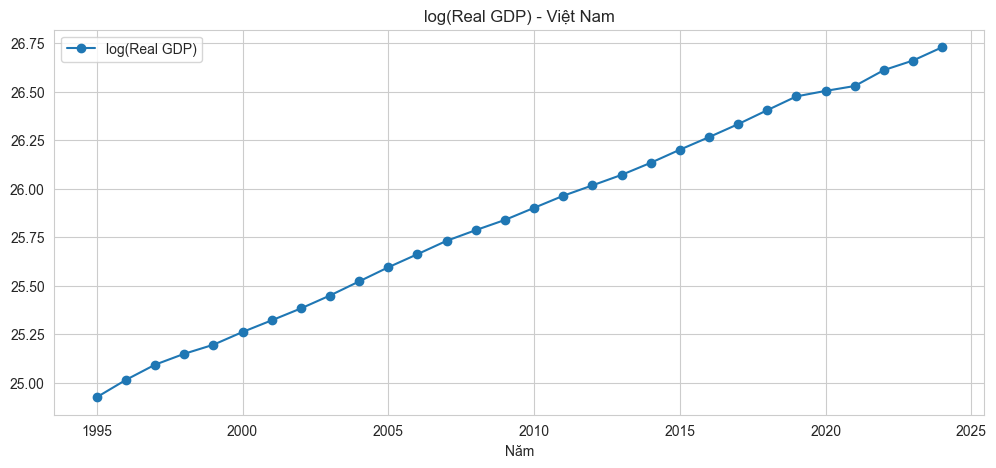

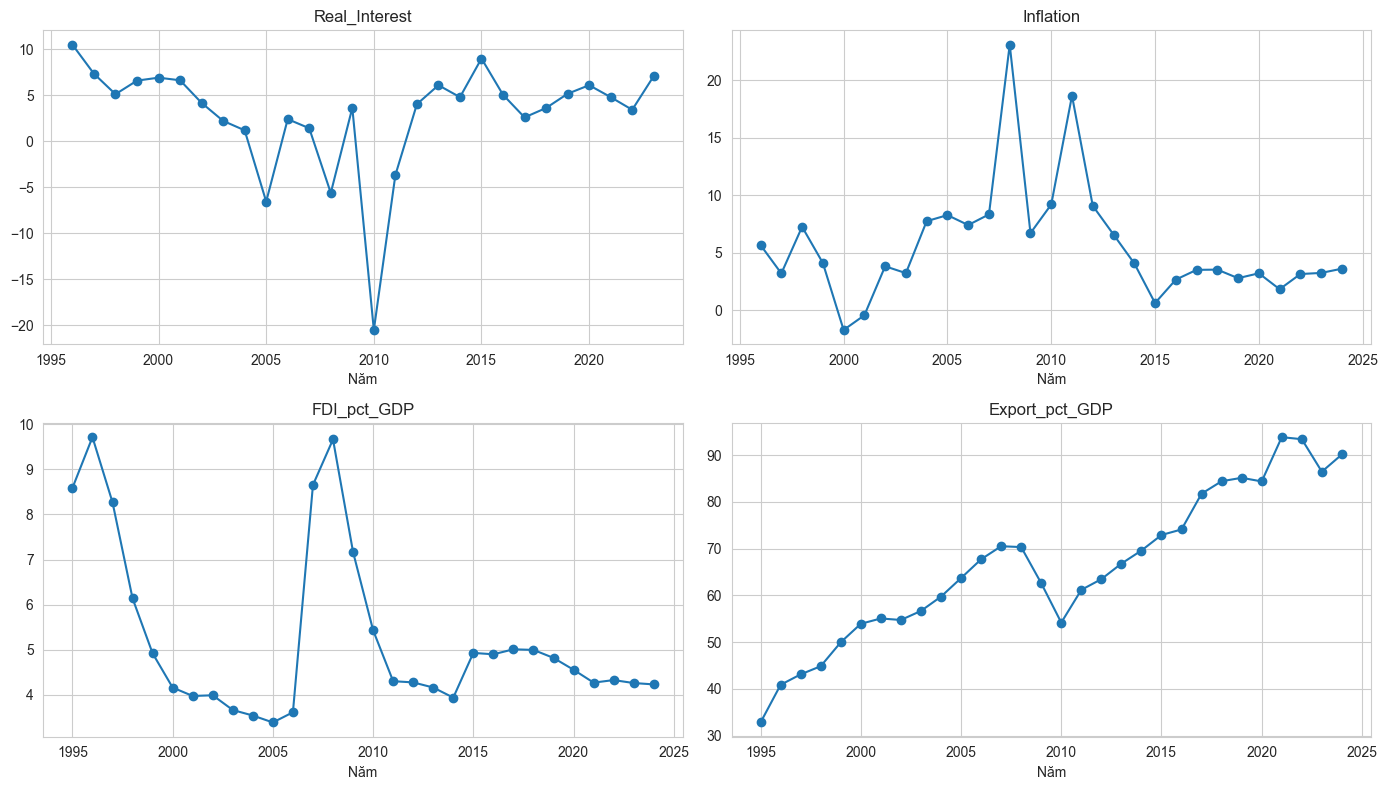

In [6]:

plt.figure(figsize=(12, 5))
plt.plot(df["Year"], df["log_real_gdp"], marker="o", label="log(Real GDP)")
plt.title("log(Real GDP) - Việt Nam")
plt.xlabel("Năm")
plt.legend()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), BASE_X):
    ax.plot(df["Year"], df[col], marker="o")
    ax.set_title(col)
    ax.set_xlabel("Năm")
plt.tight_layout()
plt.show()


## 4. Long-run equation (Engle-Granger step 1)


In [7]:

lr_df = df_model.dropna(subset=["log_real_gdp"] + BASE_X).copy()
X_lr = sm.add_constant(lr_df[BASE_X])
y_lr = lr_df["log_real_gdp"]

lr_res = sm.OLS(y_lr, X_lr).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
lr_df["ec_resid"] = lr_res.resid

display(lr_res.summary())

coef_lr = pd.DataFrame({
    "variable": lr_res.params.index,
    "coef": lr_res.params.values,
    "std_err": lr_res.bse.values,
    "p_value": lr_res.pvalues.values,
})
coef_lr.to_csv(OUTPUT_DIR / "01_long_run_coefficients.csv", index=False)
display(coef_lr)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           log_real_gdp   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     106.3
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.76e-14
Time:                        08:19:56   Log-Likelihood:                 10.218
No. Observations:                  28   AIC:                            -10.44
Df Residuals:                      23   BIC:                            -3.774
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             23.8227      0.255     93.368      0.000      23.323      24.323
Real_Interest     -0.0065      0.010     -0.638      0.524      -0.026       0.013
Inflation          0.0018      0.010      0.174      0.862      -0.019       0.022
FDI_pct_GDP       -0.0130      0.026     -0.507      0.612      -0.063       0.037
Export_pct_GDP     0.0317      0.002     14.914      0.000       0.028       0.036
==============================================================================
Omnibus:                        9.021   Durbin-Watson:                   0.522
Prob(Omnibus):                  0.011   Jarque-Bera (JB):                2.200
Skew:                           0.021   Prob(JB):                        0.333
Kurtosis:                       1.627   Cond. No.                         441.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

,variable,coef,std_err,p_value
0,const,23.822738,0.255148,0.000000e+00
1,Real_Interest,-0.006455,0.010123,5.236584e-01
2,Inflation,0.001816,0.010443,8.619145e-01
3,FDI_pct_GDP,-0.012984,0.025588,6.118498e-01
4,Export_pct_GDP,0.031719,0.002127,2.672935e-50


## 5. Kiểm định cointegration bằng residual ADF


,test,adf_stat,p_value,interpretation
0,ADF on long-run residual,-1.821327,0.369926,No strong residual-stationarity evidence


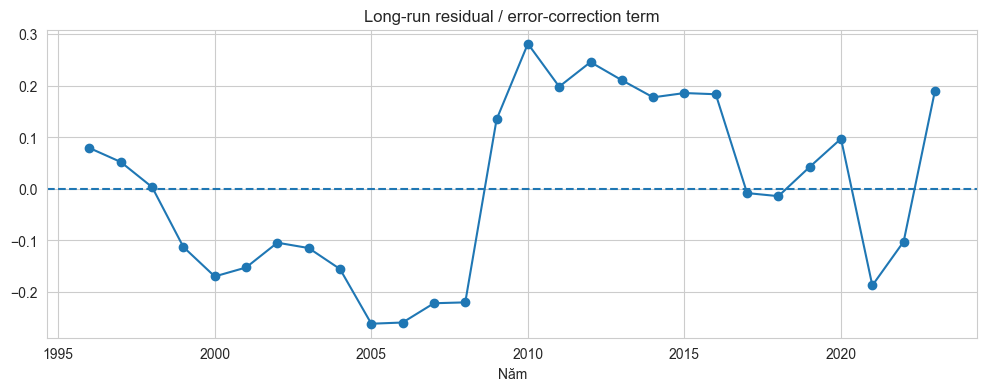

In [8]:

adf_stat, p_value, *_ = adfuller(lr_df["ec_resid"].dropna(), autolag="AIC")
resid_adf = pd.DataFrame([{
    "test": "ADF on long-run residual",
    "adf_stat": adf_stat,
    "p_value": p_value,
    "interpretation": "Cointegrated" if p_value < 0.05 else "No strong residual-stationarity evidence",
}])
resid_adf.to_csv(OUTPUT_DIR / "01_residual_adf.csv", index=False)
display(resid_adf)

plt.figure(figsize=(12, 4))
plt.plot(lr_df["Year"], lr_df["ec_resid"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Long-run residual / error-correction term")
plt.xlabel("Năm")
plt.show()


## 6. ECM (Engle-Granger step 2)

Dạng mô hình:

\[
\Delta \log(GDP_t) = \alpha + \sum \beta_i \Delta X_{i,t} + \lambda \cdot EC_{t-1} + u_t
\]

Trong đó `EC_{t-1}` là residual của phương trình dài hạn, trễ 1 kỳ.


In [9]:

ecm_df = lr_df[["Year", "log_real_gdp"] + BASE_X + ["ec_resid"]].copy()
ecm_df["d_log_real_gdp"] = ecm_df["log_real_gdp"].diff()
for col in BASE_X:
    ecm_df[f"d_{col}"] = ecm_df[col].diff()
ecm_df["ecm_lag1"] = ecm_df["ec_resid"].shift(1)
ecm_df = ecm_df.dropna().copy()

ecm_X = sm.add_constant(ecm_df[[f"d_{col}" for col in BASE_X] + ["ecm_lag1"]])
ecm_y = ecm_df["d_log_real_gdp"]
ecm_res = sm.OLS(ecm_y, ecm_X).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

display(ecm_res.summary())

coef_ecm = pd.DataFrame({
    "variable": ecm_res.params.index,
    "coef": ecm_res.params.values,
    "std_err": ecm_res.bse.values,
    "p_value": ecm_res.pvalues.values,
})
coef_ecm.to_csv(OUTPUT_DIR / "01_ecm_coefficients.csv", index=False)
display(coef_ecm)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         d_log_real_gdp   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                 -0.155
Method:                 Least Squares   F-statistic:                     1.473
Date:                Thu, 26 Mar 2026   Prob (F-statistic):              0.241
Time:                        08:19:56   Log-Likelihood:                 80.314
No. Observations:                  27   AIC:                            -148.6
Df Residuals:                      21   BIC:                            -140.9
Df Model:                           5                                         
Covariance Type:                  HAC                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0606      0.002     27.141      0.000       0.056       0.065
d_Real_Interest     -0.0002      0.000     -0.802      0.423      -0.001       0.000
d_Inflation       8.484e-05      0.000      0.238      0.812      -0.001       0.001
d_FDI_pct_GDP        0.0009      0.001      0.846      0.397      -0.001       0.003
d_Export_pct_GDP     0.0002      0.001      0.256      0.798      -0.001       0.002
ecm_lag1            -0.0137      0.010     -1.322      0.186      -0.034       0.007
==============================================================================
Omnibus:                       11.858   Durbin-Watson:                   1.720
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               10.749
Skew:                          -1.261   Prob(JB):                      0.00463
Kurtosis:                       4.786   Cond. No.                         49.8
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

,variable,coef,std_err,p_value
0,const,0.060641,0.002234,3.237669e-162
1,d_Real_Interest,-0.000220,0.000275,4.225265e-01
2,d_Inflation,0.000085,0.000357,8.119548e-01
3,d_FDI_pct_GDP,0.000888,0.001049,3.973381e-01
4,d_Export_pct_GDP,0.000221,0.000861,7.976962e-01
5,ecm_lag1,-0.013698,0.010362,1.862066e-01


In [10]:

speed = ecm_res.params.get("ecm_lag1", np.nan)
speed_p = ecm_res.pvalues.get("ecm_lag1", np.nan)

if pd.notna(speed):
    if speed < 0 and speed_p < 0.05:
        interpretation = (
            f"Hệ số hiệu chỉnh sai số = {speed:.4f} (p = {speed_p:.4f}) < 0 và có ý nghĩa. "
            "Điều này ủng hộ cơ chế quay về cân bằng dài hạn."
        )
    elif speed < 0:
        interpretation = (
            f"Hệ số hiệu chỉnh sai số = {speed:.4f} nhưng p = {speed_p:.4f}. "
            "Dấu âm đúng kỳ vọng nhưng bằng chứng thống kê chưa đủ mạnh."
        )
    else:
        interpretation = (
            f"Hệ số hiệu chỉnh sai số = {speed:.4f}, không mang dấu âm mong đợi. "
            "Cần xem lại đặc tả mô hình hoặc biến đại diện."
        )
else:
    interpretation = "Không ước lượng được hệ số hiệu chỉnh sai số."

display(Markdown("### Diễn giải tốc độ điều chỉnh"))
display(Markdown(interpretation))


### Diễn giải tốc độ điều chỉnh

Hệ số hiệu chỉnh sai số = -0.0137 nhưng p = 0.1862. Dấu âm đúng kỳ vọng nhưng bằng chứng thống kê chưa đủ mạnh.

## 7. Robustness: thay đổi định nghĩa lãi suất

Phần này rất hữu ích nếu pipeline hiện tại của bạn đang dùng `Lending_Rate` nhưng trong phần lý thuyết lại nói về **real interest rate** hoặc **policy rate**.


In [11]:

robust_rows = []
interest_candidates = ["Real_Interest", "Lending_Rate", "Deposit_Rate"]

for rate_col in interest_candidates:
    cols = ["log_real_gdp", rate_col, "Inflation", "FDI_pct_GDP", "Export_pct_GDP"]
    tmp = df_model[["Year"] + cols].dropna().copy()
    if len(tmp) < 15:
        continue

    X = sm.add_constant(tmp[[rate_col, "Inflation", "FDI_pct_GDP", "Export_pct_GDP"]])
    y = tmp["log_real_gdp"]
    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    robust_rows.append({
        "interest_measure": rate_col,
        "nobs": int(res.nobs),
        "coef_interest": float(res.params.get(rate_col, np.nan)),
        "p_value_interest": float(res.pvalues.get(rate_col, np.nan)),
        "adj_r2": float(res.rsquared_adj),
        "aic": float(res.aic),
    })

robust_df = pd.DataFrame(robust_rows).sort_values("aic")
robust_df.to_csv(OUTPUT_DIR / "01_interest_measure_robustness.csv", index=False)
display(robust_df)


,interest_measure,nobs,coef_interest,p_value_interest,adj_r2,aic
2,Deposit_Rate,27,0.137991,8.006507e-10,0.915684,-24.382607
0,Real_Interest,28,-0.006455,5.236584e-01,0.866377,-10.435259
1,Lending_Rate,28,0.010152,5.971417e-01,0.863250,-9.787501


## 8. Câu kết luận có thể dán thẳng vào báo cáo


In [12]:

summary_lines = [
    "### Kết luận gợi ý cho phần ECM",
    f"- Nguồn dữ liệu dùng để ước lượng ECM: `{source_used}`.",
]

if not resid_adf.empty:
    row = resid_adf.iloc[0]
    summary_lines.append(
        f"- Kiểm định ADF trên residual dài hạn cho p-value = {row['p_value']:.4f}; "
        + ("ủng hộ cointegration." if row["p_value"] < 0.05 else "chưa cho bằng chứng cointegration đủ mạnh.")
    )

if "ecm_lag1" in coef_ecm["variable"].values:
    erow = coef_ecm.loc[coef_ecm["variable"] == "ecm_lag1"].iloc[0]
    summary_lines.append(
        f"- Hệ số error-correction term = {erow['coef']:.4f}, p-value = {erow['p_value']:.4f}."
    )

if not robust_df.empty:
    best_measure = robust_df.iloc[0]["interest_measure"]
    summary_lines.append(
        f"- Theo AIC, định nghĩa lãi suất phù hợp nhất trong notebook robustness hiện tại là `{best_measure}`."
    )

summary_text = "\n".join(summary_lines)
display(Markdown(summary_text))

with open(OUTPUT_DIR / "01_ecm_summary.md", "w", encoding="utf-8") as f:
    f.write(summary_text)


### Kết luận gợi ý cho phần ECM
- Nguồn dữ liệu dùng để ước lượng ECM: `world_bank_api`.
- Kiểm định ADF trên residual dài hạn cho p-value = 0.3699; chưa cho bằng chứng cointegration đủ mạnh.
- Hệ số error-correction term = -0.0137, p-value = 0.1862.
- Theo AIC, định nghĩa lãi suất phù hợp nhất trong notebook robustness hiện tại là `Deposit_Rate`.